# Master's Thesis Notebook

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026


# test7 simulation

Notebook equivalent of `tests/7_atmosphere/test7_simulation.py`. The original Python test module remains the source of truth; this notebook imports it and runs each numerical test and diagnostic plot in its own cell for interactive inspection.

The notebook uses the shared TPeanuts output-root convention defined in section `2. Paths`. Generated `atmosphere` test artifacts and figures are redirected to the notebook-specific `OUTPUT_DIR` under `OUTPUT_TEST_ROOT / "atmosphere" / NOTEBOOK_STEM`.


## 1. Libraries and test module

This section locates the repository, imports the original `atmosphere` test module, and reloads it so source changes are reflected when the notebook is rerun. The expected result is that the module imports without errors. Possible problems include running the notebook from outside the repository tree, missing optional dependencies, or unavailable external model data.


In [1]:
from __future__ import annotations

import importlib
import importlib.util
import os
import sys
import traceback
from pathlib import Path

import matplotlib.pyplot as plt


from tpeanuts.util.notebooks import find_repo_root
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

NOTEBOOK_STEM = "test7_simulation"
TEST_MODULE_PATH = PACKAGE_DIR / "notebooks" / "tests" / "7_atmosphere" / f"{NOTEBOOK_STEM}.py"
TEST_MODULE_NAME = f"notebook_tests_{TEST_MODULE_PATH.parent.name.replace('.', '_')}_{NOTEBOOK_STEM}"
if not TEST_MODULE_PATH.exists():
    raise FileNotFoundError(f"Could not find local test module: {TEST_MODULE_PATH}")
spec = importlib.util.spec_from_file_location(TEST_MODULE_NAME, TEST_MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load test module spec from {TEST_MODULE_PATH}")
TEST_MODULE = importlib.util.module_from_spec(spec)
sys.modules[TEST_MODULE_NAME] = TEST_MODULE
spec.loader.exec_module(TEST_MODULE)
print("Loaded local test module:", TEST_MODULE_PATH)

from tpeanuts.util.notebooks import build_notebook_test_runner


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Loaded local test module: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\7_atmosphere\test7_simulation.py


## 2. Paths

All outputs are rooted at `DEFAULT_OUTPUT_ROOT` unless `TPEANUTS_OUTPUT_ROOT` is defined in the environment. This notebook writes `atmosphere` test figures and generated artifacts under `OUTPUT_TEST_ROOT / "atmosphere" / NOTEBOOK_STEM`, while data, analysis, benchmark, and external roots follow the same shared structure used by the analysis notebooks.


In [2]:
DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_EXTERNAL / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_EXTERNAL / "honda")

OUTPUT_DIR = OUTPUT_TEST_ROOT / "atmosphere" / NOTEBOOK_STEM
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SHOW_PLOTS = True
print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


Output root     : V:\output
Output directory: V:\output\test\atmosphere\test7_simulation


In [3]:
NOTEBOOK_RUNNER_ATTRS = {}
if "RUN_REAL_DATA_ANALYSIS" in globals():
    NOTEBOOK_RUNNER_ATTRS["RUN_REAL_mceq_run1_analysis"] = RUN_REAL_DATA_ANALYSIS

runner = build_notebook_test_runner(
    TEST_MODULE,
    OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
    auto_save_figures=True,
    extra_module_attrs=NOTEBOOK_RUNNER_ATTRS,
)
run_notebook_test = runner.run_test
run_notebook_call = runner.run_call


## Test: `test_zero_height_identity`

**What is checked:** Zero height identity behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Zero production height must return identity..

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; density backend availability, geometry conventions, or propagation-step settings can affect this check.


In [4]:
run_notebook_test(TEST_MODULE.test_zero_height_identity)


Running test_zero_height_identity ...

Zero-height identity check
x_grid span: 0.0
max |S-I| : 0.000e+00
------------------------------------------------------------------------------------------
PASSED: test_zero_height_identity


## Test: `test_vacuum_limit_matches_exact_exponential`

**What is checked:** Vacuum limit matches exact exponential behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: vacuum numerical propagator must match exact exponential..

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; density backend availability, geometry conventions, or propagation-step settings can affect this check.


In [5]:
run_notebook_test(TEST_MODULE.test_vacuum_limit_matches_exact_exponential)


Running test_vacuum_limit_matches_exact_exponential ...

vacuum exact-limit check
E [GeV]       : 1.0
h [km]        : 20.0
theta [deg]   : 45.0
L_atm [km]    : 28.235749067594043
x span        : 0.004431917919886053
||S-S_exact|| : 2.099e-14
------------------------------------------------------------------------------------------
PASSED: test_vacuum_limit_matches_exact_exponential


## Test: `test_matter_unitarity_and_norm_conservation`

**What is checked:** Matter unitarity and norm conservation behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Matter atmospheric operator must be unitary.; coherent propagation must conserve state norm..

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; density backend availability, geometry conventions, or propagation-step settings can affect this check; normalization failures often point to probability conservation or broadcasting issues.


In [6]:
run_notebook_test(TEST_MODULE.test_matter_unitarity_and_norm_conservation)


Running test_matter_unitarity_and_norm_conservation ...

Matter unitarity and norm check
max |S^dag S-I|: 4.885e-14
initial norm   : 1.000000000000
surface norm   : 1.000000000000
norm error     : 2.665e-15
------------------------------------------------------------------------------------------
PASSED: test_matter_unitarity_and_norm_conservation


## Test: `test_probability_matrix_is_physical`

**What is checked:** Probability matrix is physical behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Probability matrix contains NaN or Inf.; Probability matrix has negative values.; Probability matrix has values above one.; assert_close.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; density backend availability, geometry conventions, or propagation-step settings can affect this check; normalization failures often point to probability conservation or broadcasting issues.


In [7]:
run_notebook_test(TEST_MODULE.test_probability_matrix_is_physical)


Running test_probability_matrix_is_physical ...

Probability matrix physicality check
P(beta -> alpha):
tensor([[9.9930442644e-01, 3.3882692580e-04, 3.5674663368e-04],
        [3.3596809111e-04, 9.9241654403e-01, 7.2474878780e-03],
        [3.5960546837e-04, 7.2446290433e-03, 9.9239576549e-01]], dtype=torch.float64)
row sums: tensor([1.0000000000e+00, 1.0000000000e+00, 1.0000000000e+00], dtype=torch.float64)
col sums: tensor([1.0000000000e+00, 1.0000000000e+00, 1.0000000000e+00], dtype=torch.float64)
------------------------------------------------------------------------------------------
PASSED: test_probability_matrix_is_physical


## Test: `test_vacuum_convergence_is_stable`

**What is checked:** Vacuum convergence is stable behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: High-step vacuum error must be small..

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; density backend availability, geometry conventions, or propagation-step settings can affect this check.


In [8]:
run_notebook_test(TEST_MODULE.test_vacuum_convergence_is_stable)


Running test_vacuum_convergence_is_stable ...

vacuum convergence stability
n_steps=   8 | error=1.343e-15
n_steps=  16 | error=4.189e-16
n_steps=  32 | error=7.724e-15
n_steps=  64 | error=2.056e-14
n_steps= 128 | error=2.262e-14
n_steps= 256 | error=5.656e-14
------------------------------------------------------------------------------------------
PASSED: test_vacuum_convergence_is_stable


## Test: `test_matter_effect_is_small_but_finite_for_atmosphere`

**What is checked:** Matter effect is small but finite for atmosphere behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Matter-vacuum difference must be finite.; Matter-vacuum difference must be non-negative.; Atmospheric matter effect should remain modest for this reference point..

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; density backend availability, geometry conventions, or propagation-step settings can affect this check; solver tests may fail when optional external MCEq data or packages are not installed.


In [9]:
run_notebook_test(TEST_MODULE.test_matter_effect_is_small_but_finite_for_atmosphere)


Running test_matter_effect_is_small_but_finite_for_atmosphere ...

Atmospheric matter-vacuum difference
max |P_matter-P_vacuum|: 4.548e-11
------------------------------------------------------------------------------------------
PASSED: test_matter_effect_is_small_but_finite_for_atmosphere


## Plot: `plot_vacuum_convergence()`

**What is checked:** Vacuum convergence behavior and numerical consistency.

**Expected result:** The expected result is that the diagnostic plot call completes and writes its figure output to `OUTPUT_DIR`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; density backend availability, geometry conventions, or propagation-step settings can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Output files for `plot_vacuum_convergence()`

This block generates or validates files in `OUTPUT_DIR`:

- `test7_vacuum_convergence.png`
- `plot_vacuum_convergence_figure_001.png`

The expected result is that each relevant image or data artifact is written to disk and, for figures, also displayed inline when `SHOW_PLOTS = True`. Possible problems include a non-writable output directory, an inactive Matplotlib backend, missing optional external data, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_vacuum_convergence() ...
Saved plot: V:\output\test\atmosphere\test7_simulation\plot_vacuum_convergence_figure_001.png


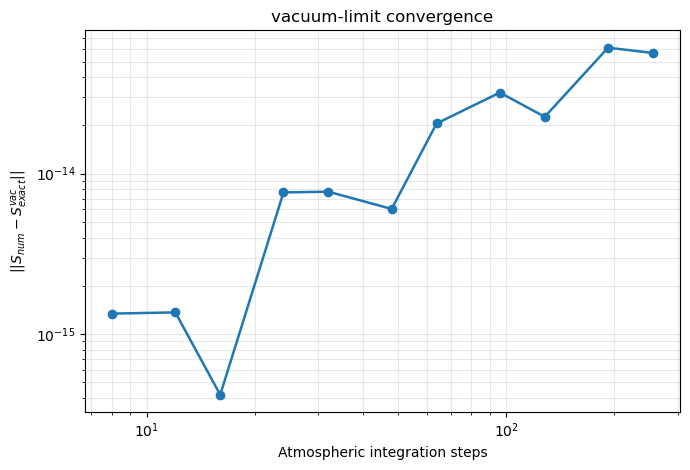

PASSED: plot_vacuum_convergence()


WindowsPath('V:/output/test/atmosphere/test7_simulation/test7_vacuum_convergence.png')

In [10]:
run_notebook_call('plot_vacuum_convergence()', lambda: TEST_MODULE.plot_vacuum_convergence())


## Plot: `plot_probability_vs_energy()`

**What is checked:** Probability vs energy behavior and numerical consistency.

**Expected result:** The expected result is that the diagnostic plot call completes and writes its figure output to `OUTPUT_DIR`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; density backend availability, geometry conventions, or propagation-step settings can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem; normalization failures often point to probability conservation or broadcasting issues.


### Output files for `plot_probability_vs_energy()`

This block generates or validates files in `OUTPUT_DIR`:

- `test7_probability_vs_energy.png`
- `plot_probability_vs_energy_figure_001.png`

The expected result is that each relevant image or data artifact is written to disk and, for figures, also displayed inline when `SHOW_PLOTS = True`. Possible problems include a non-writable output directory, an inactive Matplotlib backend, missing optional external data, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_probability_vs_energy() ...
Saved plot: V:\output\test\atmosphere\test7_simulation\plot_probability_vs_energy_figure_001.png


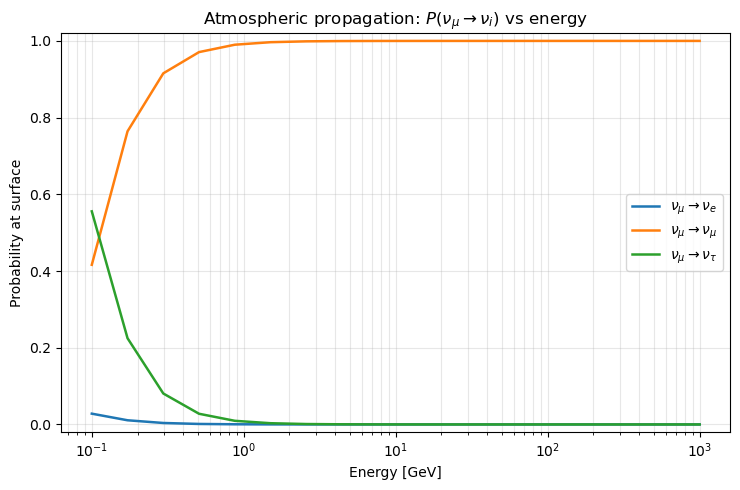

PASSED: plot_probability_vs_energy()


WindowsPath('V:/output/test/atmosphere/test7_simulation/test7_probability_vs_energy.png')

In [11]:
run_notebook_call('plot_probability_vs_energy()', lambda: TEST_MODULE.plot_probability_vs_energy())


## Plot: `plot_probability_vs_theta()`

**What is checked:** Probability vs theta behavior and numerical consistency.

**Expected result:** The expected result is that the diagnostic plot call completes and writes its figure output to `OUTPUT_DIR`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; density backend availability, geometry conventions, or propagation-step settings can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem; normalization failures often point to probability conservation or broadcasting issues.


### Output files for `plot_probability_vs_theta()`

This block generates or validates files in `OUTPUT_DIR`:

- `test7_probability_vs_theta.png`
- `plot_probability_vs_theta_figure_001.png`

The expected result is that each relevant image or data artifact is written to disk and, for figures, also displayed inline when `SHOW_PLOTS = True`. Possible problems include a non-writable output directory, an inactive Matplotlib backend, missing optional external data, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_probability_vs_theta() ...
Saved plot: V:\output\test\atmosphere\test7_simulation\plot_probability_vs_theta_figure_001.png


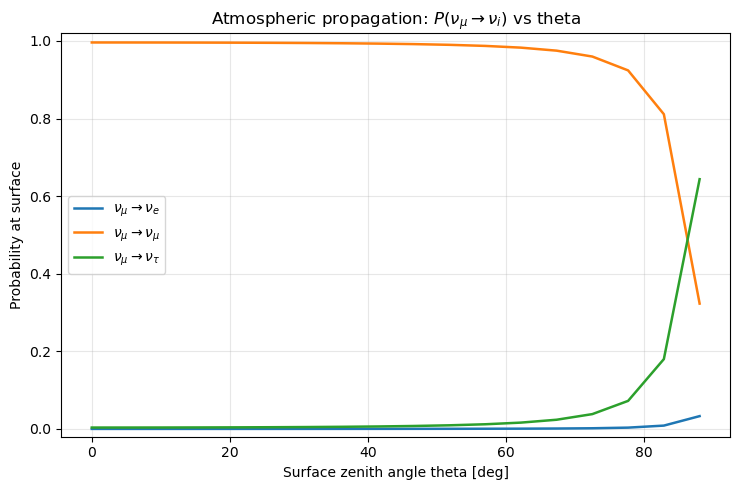

PASSED: plot_probability_vs_theta()


WindowsPath('V:/output/test/atmosphere/test7_simulation/test7_probability_vs_theta.png')

In [12]:
run_notebook_call('plot_probability_vs_theta()', lambda: TEST_MODULE.plot_probability_vs_theta())


## Plot: `plot_matter_vacuum_probability_difference()`

**What is checked:** Matter vacuum probability difference behavior and numerical consistency.

**Expected result:** The expected result is that the diagnostic plot call completes and writes its figure output to `OUTPUT_DIR`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; density backend availability, geometry conventions, or propagation-step settings can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem; normalization failures often point to probability conservation or broadcasting issues.


### Output files for `plot_matter_vacuum_probability_difference()`

This block generates or validates files in `OUTPUT_DIR`:

- `test7_matter_vacuum_difference.png`
- `plot_matter_vacuum_probability_difference_figure_001.png`

The expected result is that each relevant image or data artifact is written to disk and, for figures, also displayed inline when `SHOW_PLOTS = True`. Possible problems include a non-writable output directory, an inactive Matplotlib backend, missing optional external data, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_matter_vacuum_probability_difference() ...
Saved plot: V:\output\test\atmosphere\test7_simulation\plot_matter_vacuum_probability_difference_figure_001.png


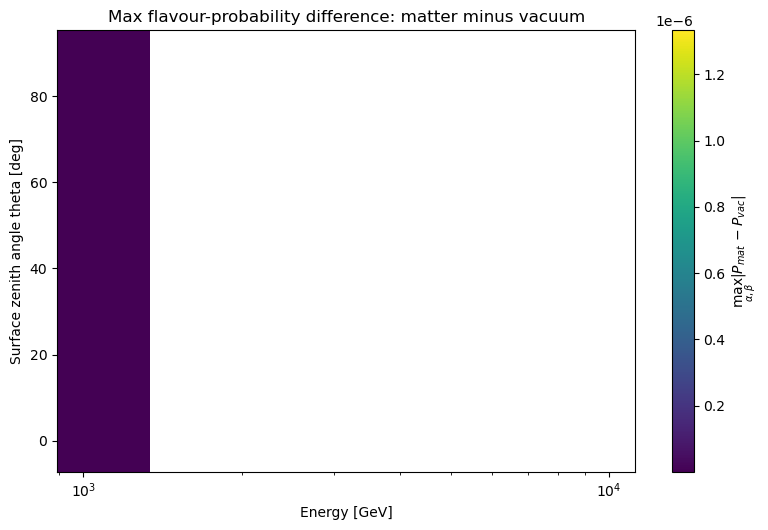

PASSED: plot_matter_vacuum_probability_difference()


WindowsPath('V:/output/test/atmosphere/test7_simulation/test7_matter_vacuum_difference.png')

In [13]:
run_notebook_call('plot_matter_vacuum_probability_difference()', lambda: TEST_MODULE.plot_matter_vacuum_probability_difference())
